In [12]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [4]:
# lectura del documento 
df = pd.read_excel('./data/online_retail_II.xlsx')
# seleccionar solo reino unido 
df = df[df['Country']=='United Kingdom']
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


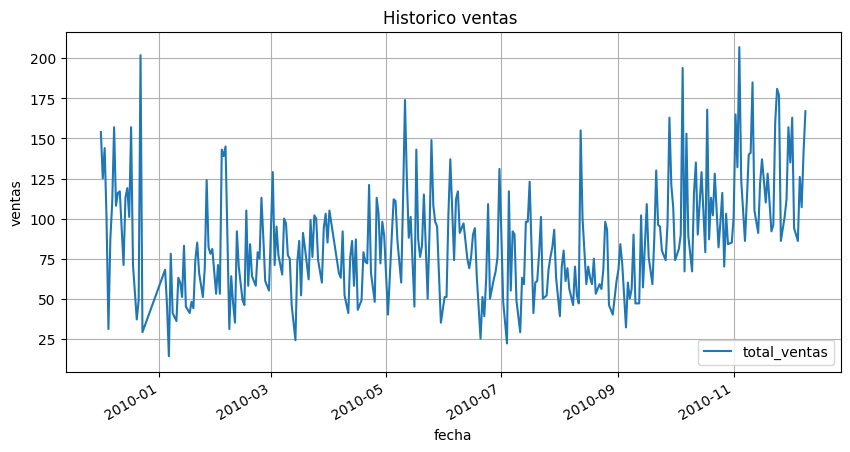

In [26]:
# Que hacer? 
# 1. Necesitamos hacer un forecast de ventas para eso usaremos Invoice para obtener el total de ventas al dia en un supermercado 

# normalizar la fecha 
df['norm_date'] = df['InvoiceDate'].dt.normalize()

ventas = df[['Invoice','norm_date']].drop_duplicates(subset='Invoice').reset_index(drop=True)

# contar por fecha la cantidad de ventas 
ventas = ventas.groupby('norm_date').agg(
    total_ventas = ('Invoice','count')
).reset_index()

# plotear
_ = ventas.set_index('norm_date')
_.plot(figsize=(10,5))
plt.grid()
plt.title('Historico ventas ')
plt.xlabel('fecha')
plt.ylabel('ventas')
plt.show()

In [ ]:
# revisar la estacionalidad 


In [37]:
# generar nuevas variables a partir de la fecha y aplicar xgboost
ventas['dia_semana'] = ventas['norm_date'].dt.dayofweek
ventas['dia_mes'] = ventas['norm_date'].dt.day
ventas['dia_ano'] = ventas['norm_date'].dt.dayofyear
ventas['mes'] = ventas['norm_date'].dt.month
ventas['estacion'] = ventas['norm_date'].dt.quarter
ventas['anio'] = ventas['norm_date'].dt.year

# variables ciclicas
# dias
ventas['dia_semana_sin'] = np.sin(2 * np.pi * ventas['dia_semana'] / 7)
ventas['dia_semana_cos'] = np.cos(2 * np.pi * ventas['dia_semana'] / 7)

# meses
ventas['mes_sin'] = np.sin(2 * np.pi * (ventas['mes'] - 1)/12)
ventas['mes_con'] = np.cos(2 * np.pi * (ventas['mes'] - 1)/12)

# definir si es dia se semana o no 
ventas['f_semana'] = ventas['dia_semana'].isin([5,6]).astype(int)

# lags
ventas['lag_1'] = ventas['total_ventas'].shift(1)
ventas['lag_3'] = ventas['total_ventas'].shift(3)
ventas['lag_6'] = ventas['total_ventas'].shift(6)

ventas

,norm_date,total_ventas,dia_semana,dia_mes,dia_ano,mes,estacion,anio,dia_semana_sin,dia_semana_cos,mes_sin,mes_con,f_semana,lag_1,lag_3,lag_6
0,2009-12-01,154,1,1,335,12,4,2009,0.781831,0.623490,-0.5,0.866025,0,NaN,NaN,NaN
1,2009-12-02,125,2,2,336,12,4,2009,0.974928,-0.222521,-0.5,0.866025,0,154.0,NaN,NaN
2,2009-12-03,144,3,3,337,12,4,2009,0.433884,-0.900969,-0.5,0.866025,0,125.0,NaN,NaN
3,2009-12-04,100,4,4,338,12,4,2009,-0.433884,-0.900969,-0.5,0.866025,0,144.0,154.0,NaN
4,2009-12-05,31,5,5,339,12,4,2009,-0.974928,-0.222521,-0.5,0.866025,1,100.0,125.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
302,2010-12-05,86,6,5,339,12,4,2010,-0.781831,0.623490,-0.5,0.866025,1,94.0,135.0,101.0
303,2010-12-06,126,0,6,340,12,4,2010,0.000000,1.000000,-0.5,0.866025,0,86.0,163.0,112.0
304,2010-12-07,107,1,7,341,12,4,2010,0.781831,0.623490,-0.5,0.866025,0,126.0,94.0,157.0
305,2010-12-08,141,2,8,342,12,4,2010,0.974928,-0.222521,-0.5,0.866025,0,107.0,86.0,135.0
